EDA Aroa

In [1]:
#Importaciones de las librerías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

In [2]:
# --- 1. Carga y Visión General Inicial ---
print("## 1. Carga y Visión General Inicial ##")
# Cargar el archivo CSV
try:
    df = pd.read_csv('../data/raw/youtoxic_english_1000.csv')
    print("DataFrame cargado exitosamente. Shape:", df.shape)
except FileNotFoundError:
    print("Error: El archivo 'youtoxic_english_1000.csv' no fue encontrado.")
    exit()

## 1. Carga y Visión General Inicial ##
DataFrame cargado exitosamente. Shape: (1000, 15)


In [3]:
# Muestra las primeras 5 filas para entender la estructura
print("\n--- Vista Previa (df.head()) ---")
print(df.head())


--- Vista Previa (df.head()) ---
              CommentId      VideoId  \
0  Ugg2KwwX0V8-aXgCoAEC  04kJtp6pVXI   
1  Ugg2s5AzSPioEXgCoAEC  04kJtp6pVXI   
2  Ugg3dWTOxryFfHgCoAEC  04kJtp6pVXI   
3  Ugg7Gd006w1MPngCoAEC  04kJtp6pVXI   
4  Ugg8FfTbbNF8IngCoAEC  04kJtp6pVXI   

                                                Text  IsToxic  IsAbusive  \
0  If only people would just take a step back and...    False      False   
1  Law enforcement is not trained to shoot to app...     True       True   
2  \nDont you reckon them 'black lives matter' ba...     True       True   
3  There are a very large number of people who do...    False      False   
4  The Arab dude is absolutely right, he should h...    False      False   

   IsThreat  IsProvocative  IsObscene  IsHatespeech  IsRacist  IsNationalist  \
0     False          False      False         False     False          False   
1     False          False      False         False     False          False   
2     False          False  

In [4]:
# Muestra información sobre el DataFrame (tipos de datos y nulos)
print("\n--- Información del DataFrame (df.info()) ---")
df.info()

print("\n" + "="*50 + "\n")


--- Información del DataFrame (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB




In [5]:
# --- 2. Tratamiento de Valores Faltantes (Missing Values) ---
print("## 2. Tratamiento de Valores Faltantes ##")

# Contar valores nulos por columna
missing_values = df.isnull().sum()
print("Conteo de valores nulos por columna:")
print(missing_values[missing_values > 0])

# Acción: Rellenar nulos en la columna 'Text' con una cadena vacía (si existen)
# Esto es crucial para el análisis de texto posterior si hay nulos
if df['Text'].isnull().any():
    df['Text'].fillna('', inplace=True)
    print("\nValores nulos en 'Text' rellenados con cadena vacía.")
else:
    print("\nNo hay valores nulos en la columna 'Text'.")

print("\n" + "="*50 + "\n")

## 2. Tratamiento de Valores Faltantes ##
Conteo de valores nulos por columna:
Series([], dtype: int64)

No hay valores nulos en la columna 'Text'.




In [6]:
# --- 3. Análisis de Variables Categóricas (Toxicidad) ---
print("## 3. Análisis de Variables Categóricas (Toxicidad) ##")

# Definir las columnas de etiquetas de toxicidad
toxic_cols = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 
              'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 
              'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

# Convertir las columnas de toxicidad a tipo numérico (si no lo están ya)
for col in toxic_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(bool).astype(int) # Asumiendo que TRUE/FALSE son strings
    elif df[col].dtype != 'int64':
        df[col] = df[col].astype(int)

## 3. Análisis de Variables Categóricas (Toxicidad) ##



--- Distribución de la clase IsToxic ---
Conteo de IsToxic (0: No Tóxico, 1: Tóxico):
IsToxic
0    538
1    462
Name: count, dtype: int64

Porcentaje de IsToxic:
IsToxic
0    53.8
1    46.2
Name: count, dtype: float64


/var/folders/gt/tfdp3g0n2430nwvd1ftk_4w80000gn/T/ipykernel_41617/3506584726.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toxic_counts.index, y=toxic_counts.values, palette=['skyblue', 'salmon'])


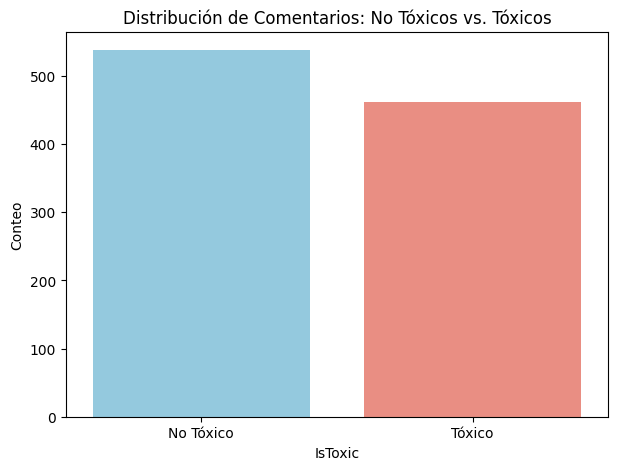

In [7]:
# 3.1. Distribución de la clase principal (IsToxic)
print("\n--- Distribución de la clase IsToxic ---")
toxic_counts = df['IsToxic'].value_counts()
toxic_percentage = toxic_counts / len(df) * 100

print(f"Conteo de IsToxic (0: No Tóxico, 1: Tóxico):\n{toxic_counts}")
print(f"\nPorcentaje de IsToxic:\n{toxic_percentage.round(2)}")

plt.figure(figsize=(7, 5))
sns.barplot(x=toxic_counts.index, y=toxic_counts.values, palette=['skyblue', 'salmon'])
plt.title('Distribución de Comentarios: No Tóxicos vs. Tóxicos')
plt.xticks([0, 1], ['No Tóxico', 'Tóxico'])
plt.ylabel('Conteo')
plt.xlabel('IsToxic')
plt.show()


OBSERVACIÓN: La clase de mayor frecuencia (No Tóxico) representa el 53.80%, indicando un **desbalance de clases**.

--- Matriz de Correlación de Tipos de Toxicidad ---


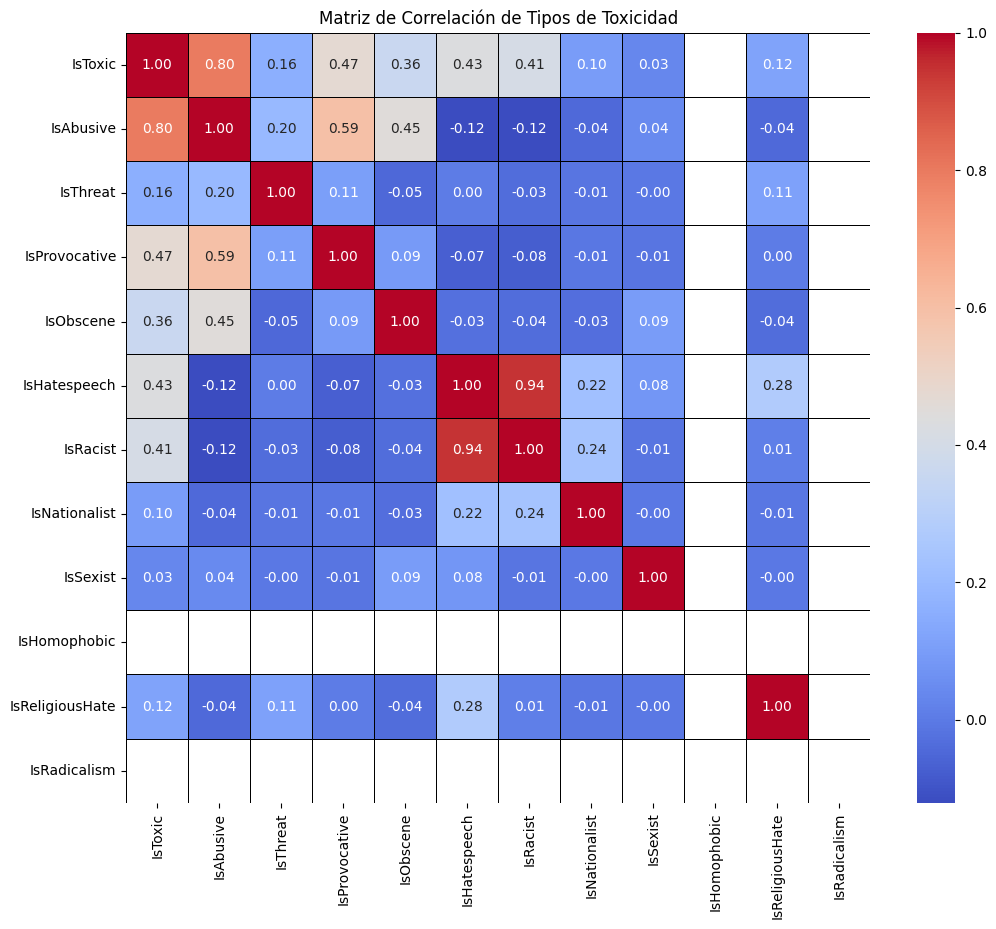



## 4. Análisis de la Variable de Texto ##

--- Estadísticas Descriptivas de la Longitud del Texto ---
count    1000.000000
mean      185.554000
std       270.780777
min         3.000000
25%        47.000000
50%       101.000000
75%       217.000000
max      4421.000000
Name: text_length, dtype: float64


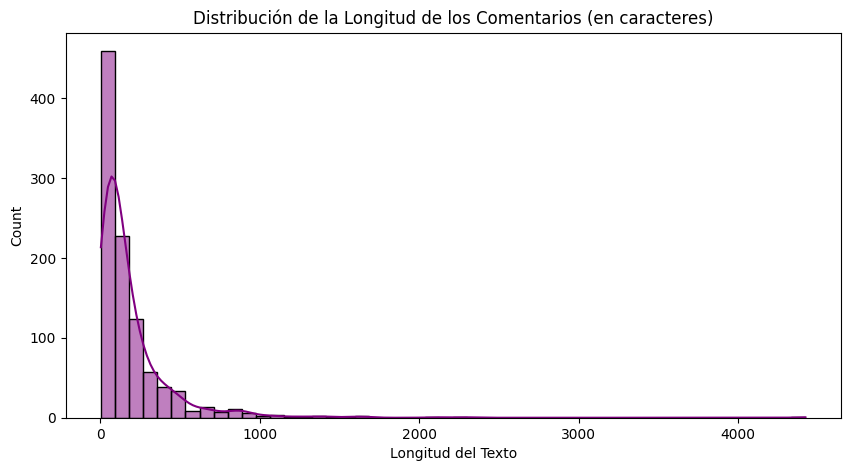


--- Longitud Promedio por Clase de Toxicidad ---
Longitud promedio de texto (0: No Tóxico, 1: Tóxico):
 IsToxic
0    182.26
1    189.39
Name: text_length, dtype: float64


/var/folders/gt/tfdp3g0n2430nwvd1ftk_4w80000gn/T/ipykernel_41617/921461309.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_length_toxic.index, y=avg_length_toxic.values, palette=['lightgreen', 'tomato'])


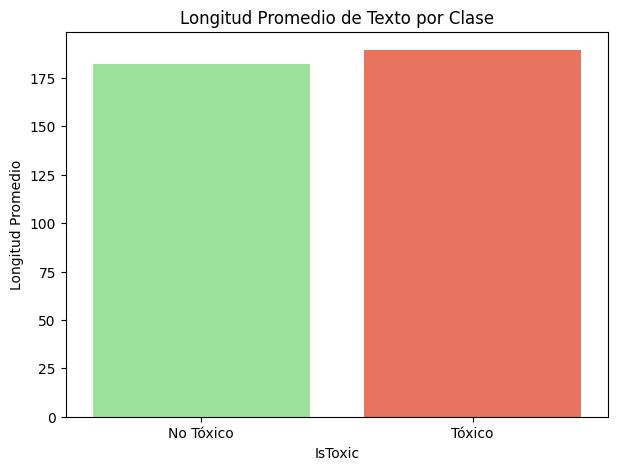

In [8]:
# Conclusión Desbalance
print(f"\nOBSERVACIÓN: La clase de mayor frecuencia (No Tóxico) representa el {toxic_percentage.max():.2f}%, indicando un **desbalance de clases**.")

# 3.2. Matriz de Correlación entre Tipos de Toxicidad
print("\n--- Matriz de Correlación de Tipos de Toxicidad ---")
correlation_matrix = df[toxic_cols].corr()

# Visualización de la matriz de correlación 
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Matriz de Correlación de Tipos de Toxicidad')
plt.show()

print("\n" + "="*50 + "\n")

# --- 4. Análisis de la Variable de Texto (Text) ---
print("## 4. Análisis de la Variable de Texto ##")

# 4.1. Longitud de los Comentarios
df['text_length'] = df['Text'].apply(len)
print("\n--- Estadísticas Descriptivas de la Longitud del Texto ---")
print(df['text_length'].describe())

# Visualización de la distribución de la longitud 
plt.figure(figsize=(10, 5))
sns.histplot(df['text_length'], bins=50, kde=True, color='purple')
plt.title('Distribución de la Longitud de los Comentarios (en caracteres)')
plt.xlabel('Longitud del Texto')
plt.show()

# 4.2. Longitud por Toxicidad
print("\n--- Longitud Promedio por Clase de Toxicidad ---")
avg_length_toxic = df.groupby('IsToxic')['text_length'].mean().round(2)
print('Longitud promedio de texto (0: No Tóxico, 1: Tóxico):\n', avg_length_toxic)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_length_toxic.index, y=avg_length_toxic.values, palette=['lightgreen', 'tomato'])
plt.title('Longitud Promedio de Texto por Clase')
plt.xticks([0, 1], ['No Tóxico', 'Tóxico'])
plt.ylabel('Longitud Promedio')
plt.show()


--- Nube de Palabras de Comentarios Tóxicos ---


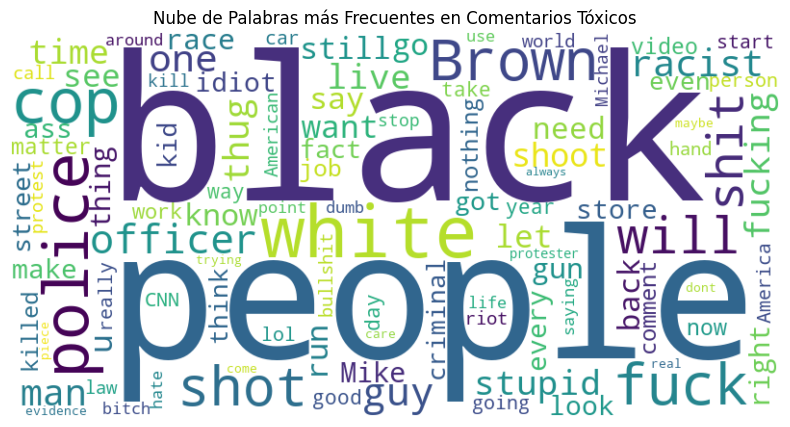

In [9]:
#4.3. Nube de Palabras (Word Cloud) para Comentarios Tóxicos
print("\n--- Nube de Palabras de Comentarios Tóxicos ---")
# Se utiliza el texto sin preprocesar para una visualización rápida.
toxic_text = " ".join(df[df['IsToxic'] == 1]['Text'].astype(str))

if toxic_text:
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100,
                          collocations=False).generate(toxic_text)
    
    # Mostrar la Nube de Palabras 
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title('Nube de Palabras más Frecuentes en Comentarios Tóxicos')
    plt.show()
else:
    print("No hay comentarios tóxicos para generar la nube de palabras.")


print("\n" + "="*50 + "\n")



## 1. Contaminación de Etiquetas (Número de Etiquetas por Comentario) ##
Distribución del número de etiquetas tóxicas aplicadas a un solo comentario:
num_toxic_labels
0    538
2    100
3    294
4     47
5     15
6      6
Name: count, dtype: int64

Porcentaje de comentarios con MÚLTIPLES etiquetas (> 1): 46.20%


/var/folders/gt/tfdp3g0n2430nwvd1ftk_4w80000gn/T/ipykernel_41617/793044345.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='plasma')


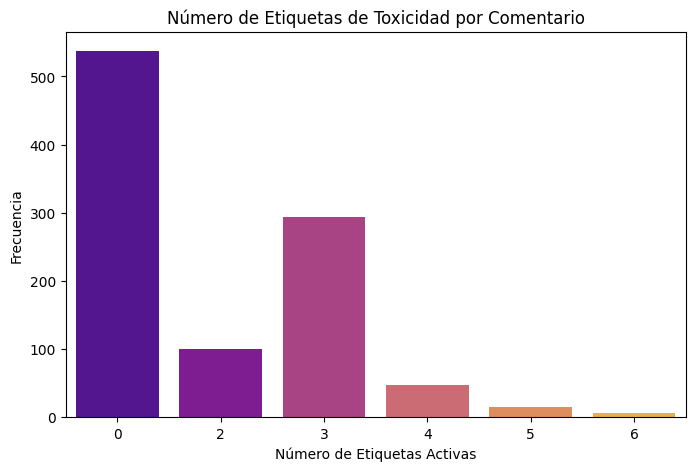

In [10]:
# --- 1. Contaminación de Etiquetas ---
print("## 1. Contaminación de Etiquetas (Número de Etiquetas por Comentario) ##")

# Columnas de toxicidad
toxic_cols = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 
              'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 
              'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

# Calcular el número de etiquetas "activas" (valor 1) por cada fila (comentario)
df['num_toxic_labels'] = df[toxic_cols].sum(axis=1)

# Distribución de la cantidad de etiquetas
label_counts = df['num_toxic_labels'].value_counts().sort_index()

print("Distribución del número de etiquetas tóxicas aplicadas a un solo comentario:")
print(label_counts)

# Porcentaje de comentarios con múltiples etiquetas (num_toxic_labels > 1)
multi_label_percentage = (df['num_toxic_labels'] > 1).sum() / len(df) * 100
print(f"\nPorcentaje de comentarios con MÚLTIPLES etiquetas (> 1): {multi_label_percentage:.2f}%")

# Visualización 
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='plasma')
plt.title('Número de Etiquetas de Toxicidad por Comentario')
plt.xlabel('Número de Etiquetas Activas')
plt.ylabel('Frecuencia')
plt.show()

In [12]:
# --- 5. Resumen de Conclusiones del EDA ---
print("## 5. Resumen de Conclusiones Clave del EDA ##")
print("* **Valores Faltantes:** Se rellenaron los valores nulos en la columna 'Text' con cadenas vacías para evitar errores de procesamiento.")
print(f"* **Desbalance de Clases:** El conjunpip install nltk scikit-learn pandas matplotlib seabornto de datos está **desequilibrado**, con aproximadamente el {toxic_percentage[0]:.2f}% de comentarios No Tóxicos y el {toxic_percentage[1]:.2f}% de Tóxicos. Esto requerirá técnicas como *oversampling* o *undersampling*.")
print("* **Correlación:** Las categorías de toxicidad están altamente correlacionadas (p.ej., `IsRacist` tiene alta correlación con `IsHatespeech`), lo cual es esperado.")
print(f"* **Longitud del Texto:** La longitud media de los textos tóxicos ({avg_length_toxic[1]:.2f} caracteres) y no tóxicos ({avg_length_toxic[0]:.2f} caracteres) es similar, aunque es posible que los comentarios tóxicos tiendan a ser ligeramente más largos o más cortos (revisar la visualización).")
print("* **Palabras Clave:** La Nube de Palabras proporciona una visión inicial de los términos más comunes utilizados en los comentarios tóxicos.")

## 5. Resumen de Conclusiones Clave del EDA ##
* **Valores Faltantes:** Se rellenaron los valores nulos en la columna 'Text' con cadenas vacías para evitar errores de procesamiento.
* **Desbalance de Clases:** El conjunpip install nltk scikit-learn pandas matplotlib seabornto de datos está **desequilibrado**, con aproximadamente el 53.80% de comentarios No Tóxicos y el 46.20% de Tóxicos. Esto requerirá técnicas como *oversampling* o *undersampling*.
* **Correlación:** Las categorías de toxicidad están altamente correlacionadas (p.ej., `IsRacist` tiene alta correlación con `IsHatespeech`), lo cual es esperado.
* **Longitud del Texto:** La longitud media de los textos tóxicos (189.39 caracteres) y no tóxicos (182.26 caracteres) es similar, aunque es posible que los comentarios tóxicos tiendan a ser ligeramente más largos o más cortos (revisar la visualización).
* **Palabras Clave:** La Nube de Palabras proporciona una visión inicial de los términos más comunes utilizados en los comentari